# Generative Models with PyTorch (VAE , GAN)

## 1. Setup Environment

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import animation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Load MNIST Dataset

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

### Visualize Samples

Text(0.5, 1.0, 'MNIST Samples')

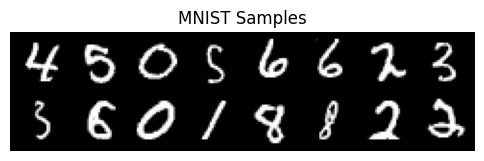

In [ ]:
images, labels = next(iter(loader))
plt.figure(figsize=(6,4))
plt.imshow(make_grid(images[:16], nrow=8).permute(1,2,0))
plt.axis("off")
plt.title("MNIST Samples")

# PART 1 — Variational Autoencoder

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,400),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(400,latent_dim)
        self.fc_logvar = nn.Linear(400,latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim,400),
            nn.ReLU(),
            nn.Linear(400,784),
            nn.Sigmoid()
        )

    def encode(self,x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu,logvar

    def reparameterize(self,mu,logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std  # z = mu + epsilon * std

    def decode(self,z):
        return self.decoder(z)

    def forward(self,x):
        mu,logvar = self.encode(x)
        z = self.reparameterize(mu,logvar)
        x_hat = self.decode(z)
        return x_hat,mu,logvar

## VAE Loss Function (Mathematical Form)

The Variational Autoencoder (VAE) loss consists of two components:

$$
\mathcal{L} = \mathcal{L}_{recon} + \mathcal{L}_{KL}
$$

---

### 1. Reconstruction Loss

In the code we compute Binary Cross Entropy between the original input $x$ and the reconstructed output $\hat{x}$:

$$
\mathcal{L}_{recon} =
-\sum_{i=1}^{D}
\left[
x_i \log(\hat{x}_i) +
(1 - x_i)\log(1 - \hat{x}_i)
\right]
$$

Where:

- $x_i$ = original pixel value  
- $\hat{x}_i$ = reconstructed pixel value  
- $D$ = total number of pixels (784 for MNIST)

This corresponds to:

```python
recon = nn.functional.binary_cross_entropy(
    x_hat, x.view(-1,784), reduction="sum"
)
```

---

### 2. KL Divergence Loss

The encoder does not produce a single latent vector directly.  
Instead, it predicts the **parameters of a Gaussian distribution**:

$$
q(z|x) = \mathcal{N}(\mu, \sigma^2)
$$

where:

- $\mu$ = mean of the latent distribution  
- $\sigma^2$ = variance of the latent distribution  

During training, we want this learned distribution to remain close to a **standard normal prior**:

$$
p(z) = \mathcal{N}(0,1)
$$

The difference between these two distributions is measured using **Kullback–Leibler (KL) Divergence**.

For two Gaussian distributions, the KL divergence has the closed-form expression:

$$
\mathcal{L}_{KL} =
-\frac{1}{2}
\sum_{j=1}^{d}
\left(
1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2
\right)
$$

where:

- $d$ = latent dimension  
- $\mu_j$ = mean of latent variable $j$  
- $\sigma_j^2$ = variance of latent variable $j$

Since the network predicts **log variance** (`logvar`), we compute:

$$
\sigma^2 = e^{\text{logvar}}
$$

This corresponds to the PyTorch implementation:

```python
kl = -0.5 * torch.sum(
    1 + logvar - mu.pow(2) - logvar.exp()
)

In [ ]:
def vae_loss(x,x_hat,mu,logvar):
    recon = nn.functional.binary_cross_entropy(
        x_hat, x.view(-1,784), reduction="sum"   # x.view(-1, 784) = flattens each 28×28 image into a 784-dimensional vector so it matches the decoder output shape during reconstruction loss calculation.
                                                 # -1 Automatically infer this dimension.  (-1, 784) => (64, 784) if batch size is 64
        )
    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    return recon + kl


## Train VAE

In [ ]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
epochs = 5
loss_history = []
for epoch in range(epochs):
    total_loss = 0
    for images,_ in loader:
        images = images.to(device)
        optimizer.zero_grad()
        x_hat,mu,logvar = vae(images) #calling forwaed
        loss = vae_loss(images,x_hat,mu,logvar)
        loss.backward() #compute gradient
        optimizer.step() #update parameters
        total_loss += loss.item()
    avg = total_loss / len(loader.dataset)
    loss_history.append(avg)
    print("Epoch",epoch+1,"Loss",avg)

Epoch 1 Loss 190.46320830078125
Epoch 2 Loss 167.10644361979166
Epoch 3 Loss 163.1412623372396
Epoch 4 Loss 160.88726681315103
Epoch 5 Loss 159.21190403645832


### Plot Training Loss

Text(0, 0.5, 'Loss')

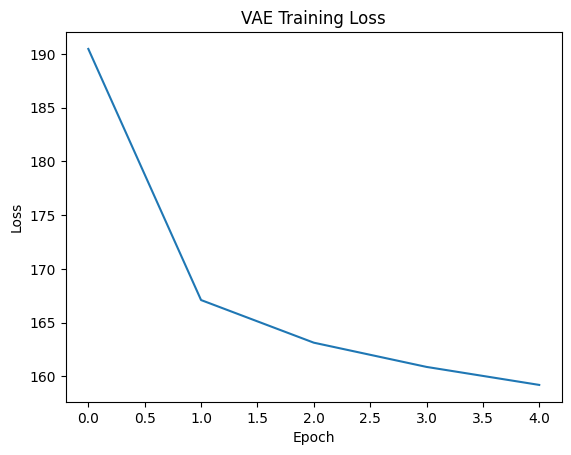

In [ ]:
plt.plot(loss_history)
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

## 2D Latent Space Visualization

Text(0.5, 1.0, '2D Latent Space')

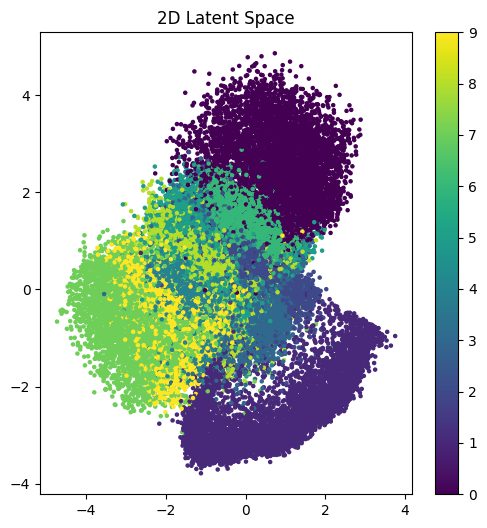

In [ ]:
latents = []
labels_list = []
with torch.no_grad():
    for images,labels in loader:
        images = images.to(device)
        mu,_ = vae.encode(images)
        latents.append(mu.cpu())
        labels_list.append(labels)
latents = torch.cat(latents)
labels_list = torch.cat(labels_list)
plt.figure(figsize=(6,6))
scatter = plt.scatter(latents[:,0], latents[:,1], c=labels_list, s=5)
plt.colorbar(scatter)
plt.title("2D Latent Space")

## VAE Perturbation: Digit 3 → Digit 6

Text(0.5, 1.0, 'Digit 3 → Digit 6 Transformation')

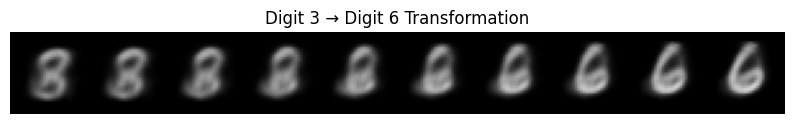

In [ ]:
img3 = None
img6 = None
for img,label in dataset:
    if label==3 and img3 is None:
        img3 = img
    if label==6 and img6 is None:
        img6 = img
    if img3 is not None and img6 is not None:
        break
img3 = img3.unsqueeze(0).to(device)
img6 = img6.unsqueeze(0).to(device)
with torch.no_grad():
    z3,_ = vae.encode(img3)
    z6,_ = vae.encode(img6)
alphas = torch.linspace(0,1,10)
samples = []
for a in alphas:
    z = (1-a)*z3 + a*z6
    out = vae.decode(z)
    samples.append(out.view(1,1,28,28))
samples = torch.cat(samples)
plt.figure(figsize=(10,2))
plt.imshow(make_grid(samples.cpu(), nrow=10).permute(1,2,0))
plt.axis("off")
plt.title("Digit 3 → Digit 6 Transformation")

# PART 2 — GAN

In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim,256),
            nn.ReLU(),
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512,784),
            nn.Tanh()
        )

    def forward(self,z):
        x = self.net(z)
        return x.view(-1,1,28,28)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,512),
            nn.LeakyReLU(0.2),
            nn.Linear(512,256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.net(x)

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
g_opt = optim.Adam(G.parameters(),lr=0.0002)
d_opt = optim.Adam(D.parameters(),lr=0.0002)
noise_dim = 100

## Train GAN with Image Snapshots

In [ ]:
epochs = 50
snapshots = []
for epoch in range(epochs):
    for images,_ in loader:
        batch = images.size(0)
        images = images.to(device)
        real = torch.ones(batch,1).to(device)
        fake = torch.zeros(batch,1).to(device)

        # Train Discriminator
        d_opt.zero_grad()
        real_loss = criterion(D(images), real)
        z = torch.randn(batch,noise_dim).to(device)
        fake_images = G(z)
        fake_loss = criterion(D(fake_images.detach()), fake)
        d_loss = real_loss + fake_loss
        d_loss.backward()
        d_opt.step()

        # Train Generator
        g_opt.zero_grad()
        z = torch.randn(batch,noise_dim).to(device)
        fake_images = G(z)
        g_loss = criterion(D(fake_images), real)
        g_loss.backward()
        g_opt.step()

    with torch.no_grad():
        z = torch.randn(16,noise_dim).to(device)
        fake = G(z).cpu()
        snapshots.append(fake)
    print("Epoch",epoch+1)

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50


## Animated GAN Training

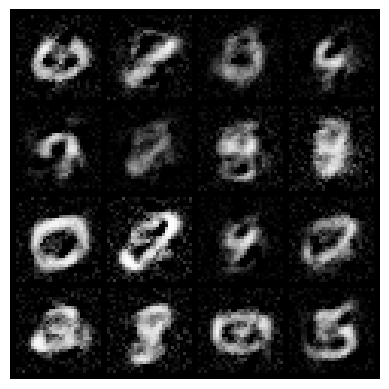

In [ ]:
from IPython.display import HTML
import matplotlib.animation as animation

fig = plt.figure()
frames = []

for imgs in snapshots:
    grid = make_grid(imgs, nrow=4).permute(1,2,0).cpu().numpy()
    frames.append([plt.imshow(grid, animated=True)])

ani = animation.ArtistAnimation(fig, frames, interval=500, blit=True)

plt.axis("off")

HTML(ani.to_jshtml())

## VAE vs GAN Comparison

(np.float64(-0.5), np.float64(121.5), np.float64(121.5), np.float64(-0.5))

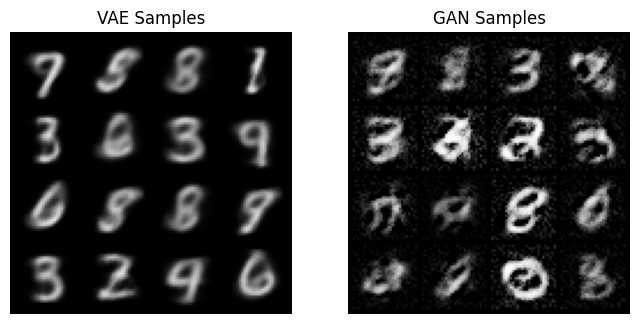

In [ ]:
with torch.no_grad():
    z = torch.randn(16,2).to(device)
    vae_samples = vae.decode(z).view(-1,1,28,28)
    z = torch.randn(16,100).to(device)
    gan_samples = G(z)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(make_grid(vae_samples.cpu(),nrow=4).permute(1,2,0))
plt.title("VAE Samples")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(make_grid(gan_samples.cpu(),nrow=4).permute(1,2,0))
plt.title("GAN Samples")
plt.axis("off")

# TO-DO

Implement **ALL** of the following:

## Experiment A
Train the VAE with **latent dimension = 10** and compare the latent visualization.

## Experiment B
Train the GAN on the **FashionMNIST** dataset.

## Experiment C
Modify the Generator to use **ConvTranspose layers**.

---

## Report Requirement

Write a short report explaining:

- What changed in the results  
- Which model produced better samples

# Experiment A — VAE with Latent Dimension = 10

In [ ]:
vae_10 = VAE(latent_dim=10).to(device)
optimizer_10 = optim.Adam(vae_10.parameters(), lr=1e-3)

epochs = 10
loss_history_10 = []

for epoch in range(epochs):
    total_loss = 0

    for images, _ in loader:
        images = images.to(device)

        x_hat, mu, logvar = vae_10(images)

        loss = vae_loss(images, x_hat, mu, logvar)

        optimizer_10.zero_grad()
        loss.backward()
        optimizer_10.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history_10.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")


In [ ]:
plt.plot(loss_history_10)
plt.title("VAE (Latent Dimension = 10) Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


## Compare Latent Space

In [ ]:
latents_10 = []
labels_10 = []

with torch.no_grad():
    for images, labels in loader:
        images = images.to(device)

        _, mu, _ = vae_10(images)

        latents_10.append(mu.cpu())
        labels_10.append(labels)

latents_10 = torch.cat(latents_10)
labels_10 = torch.cat(labels_10)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    latents_10[:,0],
    latents_10[:,1],
    c=labels_10,
    cmap='tab10',
    s=5
)

plt.colorbar(scatter)
plt.title("VAE Latent Space (latent_dim = 10)")
plt.show()


# Experiment B — GAN on FashionMNIST

In [ ]:
fashion_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

fashion_loader = torch.utils.data.DataLoader(
    fashion_dataset,
    batch_size=128,
    shuffle=True
)

images, labels = next(iter(fashion_loader))

plt.figure(figsize=(6,6))
plt.imshow(make_grid(images[:16], nrow=4).permute(1,2,0))
plt.title("FashionMNIST Samples")
plt.axis("off")
plt.show()


In [ ]:
G_fashion = Generator().to(device)
D_fashion = Discriminator().to(device)

g_optimizer = optim.Adam(G_fashion.parameters(), lr=2e-4)
d_optimizer = optim.Adam(D_fashion.parameters(), lr=2e-4)

criterion = nn.BCELoss()

epochs = 10

for epoch in range(epochs):

    for real_images, _ in fashion_loader:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        noise = torch.randn(batch_size, 100).to(device)
        fake_images = G_fashion(noise)

        real_loss = criterion(D_fashion(real_images), real_labels)
        fake_loss = criterion(D_fashion(fake_images.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        noise = torch.randn(batch_size, 100).to(device)
        fake_images = G_fashion(noise)

        g_loss = criterion(D_fashion(fake_images), real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


In [ ]:
with torch.no_grad():
    noise = torch.randn(16,100).to(device)
    generated_fashion = G_fashion(noise).cpu()

plt.figure(figsize=(6,6))
plt.imshow(make_grid(generated_fashion, nrow=4).permute(1,2,0))
plt.title("FashionMNIST GAN Samples")
plt.axis("off")
plt.show()


# Experiment C — Generator with ConvTranspose Layers

In [ ]:
class ConvGenerator(nn.Module):

    def __init__(self, noise_dim=100):
        super().__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(noise_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.model(z)

conv_G = ConvGenerator().to(device)

noise = torch.randn(16,100).to(device)

with torch.no_grad():
    samples = conv_G(noise).cpu()

plt.figure(figsize=(6,6))
plt.imshow(make_grid(samples, nrow=4, normalize=True).permute(1,2,0))
plt.title("ConvTranspose Generator Samples")
plt.axis("off")
plt.show()


# Short Report

## Experiment A — Latent Dimension = 10

Increasing the latent dimension from 2 to 10 gave the VAE a larger feature space to encode information.  
The reconstructed images became smoother and slightly more detailed. However, the latent space visualization became harder to interpret because only two dimensions were plotted from a 10-dimensional space.

## Experiment B — GAN on FashionMNIST

Training the GAN on FashionMNIST was more difficult than MNIST because clothing images are more complex than handwritten digits.  
The generated samples initially looked noisy, but improved gradually after several epochs.

## Experiment C — ConvTranspose Generator

Using ConvTranspose layers improved the generator architecture because convolutional operations preserve spatial structure better than fully connected layers.  
The generated images appeared sharper and more realistic compared to the original generator.

## Final Comparison

- The VAE produced smoother but blurrier samples.
- The GAN produced sharper and more realistic samples.
- The ConvTranspose GAN generated the best visual quality overall.

Therefore, the GAN with convolutional layers produced the best samples in this lab.
